<a href="https://colab.research.google.com/github/ariaesoares/Challenge-Telecom-X/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [83]:
import pandas as pd

In [84]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

In [85]:
dados = pd.read_json(url)

In [86]:
dados.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [87]:
info_clientes = pd.json_normalize(dados['customer']).add_prefix('customer.')
info_phone = pd.json_normalize(dados['phone']).add_prefix('phone.')
info_internet = pd.json_normalize(dados['internet']).add_prefix('internet.')
info_account = pd.json_normalize(dados['account']).add_prefix('account.')

In [88]:
dados_normalizados = pd.concat([dados[['customerID', 'Churn']], info_clientes, info_phone, info_internet, info_account], axis=1)
dados_normalizados.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

In [89]:
dados_normalizados

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [90]:
dados_normalizados.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [91]:
import numpy as np

In [92]:
dados_normalizados.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


1. Verificação de valores unicos:

In [93]:
for col in dados_normalizados.columns:
  print(f'{col}: {dados_normalizados[col].unique()}')

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn: ['No' 'Yes' '']
customer.gender: ['Female' 'Male']
customer.SeniorCitizen: [0 1]
customer.Partner: ['Yes' 'No']
customer.Dependents: ['Yes' 'No']
customer.tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
phone.PhoneService: ['Yes' 'No']
phone.MultipleLines: ['No' 'Yes' 'No phone service']
internet.InternetService: ['DSL' 'Fiber optic' 'No']
internet.OnlineSecurity: ['No' 'Yes' 'No internet service']
internet.OnlineBackup: ['Yes' 'No' 'No internet service']
internet.DeviceProtection: ['No' 'Yes' 'No internet service']
internet.TechSupport: ['Yes' 'No' 'No internet service']
internet.StreamingTV: ['Yes' 'No' 'No internet service']
internet.StreamingMovies: ['No' 'Yes' 'No internet service']
account.Contrac

In [94]:
print('Número de valores duplicados', dados_normalizados.duplicated().sum())

Número de valores duplicados 0


In [95]:
print('Número de valores nulos', dados_normalizados.isnull().sum())

Número de valores nulos customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [96]:
print('Número de valores nulos', dados_normalizados.isnull().sum())

Número de valores nulos customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


In [97]:
dados_normalizados.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [98]:
dados_normalizados['account.Charges.Total'] = pd.to_numeric(dados_normalizados['account.Charges.Total'], errors='coerce')

In [99]:
dados_normalizados.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [100]:
df = dados_normalizados[dados_normalizados['Churn'].str.strip() != '']
print('Número de linhas depois de eliminar as vazias em "Churn":', len(df))

Número de linhas depois de eliminar as vazias em "Churn": 7043


In [101]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [102]:
df = df.dropna(subset=['account.Charges.Total'])

In [103]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [104]:
df['contas diárias'] = (df['account.Charges.Monthly']/30).round(2)
df['contas diárias']

,contas diárias
0,2.19
1,2.00
2,2.46
3,3.27
4,2.80
...,...
7262,1.84
7263,2.84
7264,1.68
7265,2.26


##Tradução

In [105]:
colunas = {'customerID': 'id',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'tem_60',
    'customer.Partner': 'possui_parceiro',
    'customer.Dependents': 'possui_dependentes',
    'customer.tenure': 'tempo_contrato',
    'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas',
    'internet.InternetService': 'tipo_internet',
    'internet.OnlineSecurity': 'seguranca_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo',
    'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTv': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento',
    'account.Charges.Monthly': 'valor_mensal',
    'account.Charges.Total': 'total_cobrado'}

In [106]:
df = df.rename(columns = colunas)

In [107]:
colunas_para_traduzir = ['Churn', 'possui_parceiro', 'possui_dependentes', 'servico_telefone', 'multiplas_linhas', 'suporte_tecnico', 'internet.StreamingTV','streaming_filmes', 'fatura_digital', 'seguranca_online', 'backup_online','protecao_dispositivo', 'tipo_contrato']

In [108]:
df['genero'] = df['genero'].replace({'Female': 'Feminino', 'Male':'Masculino'})
df['tipo_internet'] = df['tipo_internet'].replace({'Fiber optic': 'Fibra óptica','No': 'Não'})
df['tipo_contrato'] = df['tipo_contrato'].replace({
    'One year': 'Um ano',
    'Month-to-month': 'Mês a mês',
    'Two year': 'Dois anos'})
df['metodo_pagamento'] = df['metodo_pagamento'].replace({
    'Mailed check': 'Cheque enviado',
    'Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)',
    'Bank transfer (automatic)': 'Transferência bancária (automática)'})
df['multiplas_linhas'] = df['multiplas_linhas'].replace({'No phone service':'Sem serviço de telefone'})


In [109]:
df[colunas_para_traduzir] = df[colunas_para_traduzir].replace({'No': 'Não', 'Yes': 'Sim', 'No internet service':'Sem serviço de internet'})

In [110]:
df.head()

,id,Churn,genero,tem_60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,internet.StreamingTV,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas diárias
0,0002-ORFBO,Não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Um ano,Sim,Cheque enviado,65.6,593.30,2.19
1,0003-MKNFE,Não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mês a mês,Não,Cheque enviado,59.9,542.40,2.00
2,0004-TLHLJ,Sim,Masculino,0,Não,Não,4,Sim,Não,Fibra óptica,...,Sim,Não,Não,Não,Mês a mês,Sim,Cheque eletrônico,73.9,280.85,2.46
3,0011-IGKFF,Sim,Masculino,1,Sim,Não,13,Sim,Não,Fibra óptica,...,Sim,Não,Sim,Sim,Mês a mês,Sim,Cheque eletrônico,98.0,1237.85,3.27
4,0013-EXCHZ,Sim,Feminino,1,Sim,Não,3,Sim,Não,Fibra óptica,...,Não,Sim,Sim,Não,Mês a mês,Sim,Cheque enviado,83.9,267.40,2.80


In [111]:
for col in df.columns:
  print(f'{col}: {df[col].unique()}')

id: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Churn: ['Não' 'Sim']
genero: ['Feminino' 'Masculino']
tem_60: [0 1]
possui_parceiro: ['Sim' 'Não']
possui_dependentes: ['Sim' 'Não']
tempo_contrato: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
servico_telefone: ['Sim' 'Não']
multiplas_linhas: ['Não' 'Sim' 'Sem serviço de telefone']
tipo_internet: ['DSL' 'Fibra óptica' 'Não']
seguranca_online: ['Não' 'Sim' 'Sem serviço de internet']
backup_online: ['Sim' 'Não' 'Sem serviço de internet']
protecao_dispositivo: ['Não' 'Sim' 'Sem serviço de internet']
suporte_tecnico: ['Sim' 'Não' 'Sem serviço de internet']
internet.StreamingTV: ['Sim' 'Não' 'Sem serviço de internet']
streaming_filmes: ['Não' 'Sim' 'Sem serviço de internet']
tipo_contrato: ['Um ano' 'Mês a mês' 'Dois anos']
fatura

In [128]:
df.to_json('telecomx_dados_tratados')

# 📊 Carga e análise

## Analise descritiva

In [112]:
df.describe()

,tem_60,tempo_contrato,valor_mensal,total_cobrado,contas diárias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159891
std,0.368844,24.545260,30.085974,2266.771362,1.002955
min,0.000000,1.000000,18.250000,18.800000,0.610000
25%,0.000000,9.000000,35.587500,401.450000,1.187500
50%,0.000000,29.000000,70.350000,1397.475000,2.340000
75%,0.000000,55.000000,89.862500,3794.737500,2.992500
max,1.000000,72.000000,118.750000,8684.800000,3.960000


In [113]:
import matplotlib as plt
import matplotlib.pyplot as plt

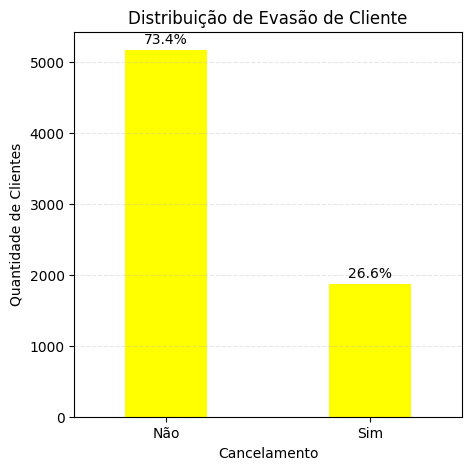

In [114]:
ax = df['Churn'].value_counts().plot(kind = 'bar', figsize=(5,5), color='yellow', width=0.4, xlabel = 'Cancelamento', ylabel = 'Quantidade de Clientes', title = 'Distribuição de Evasão de Cliente', rot=(0))
contagem_churn = df['Churn'].value_counts()
churn_porcentagem = (contagem_churn / len(df)) * 100
plt.grid(axis='y', linestyle='--', alpha=0.3)
for i, percentage in enumerate(churn_porcentagem):

    ax.text(i, contagem_churn.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')

[Text(0, 3, '23.5%'), Text(0, 3, '2.4%'), Text(0, 3, '0.7%')]

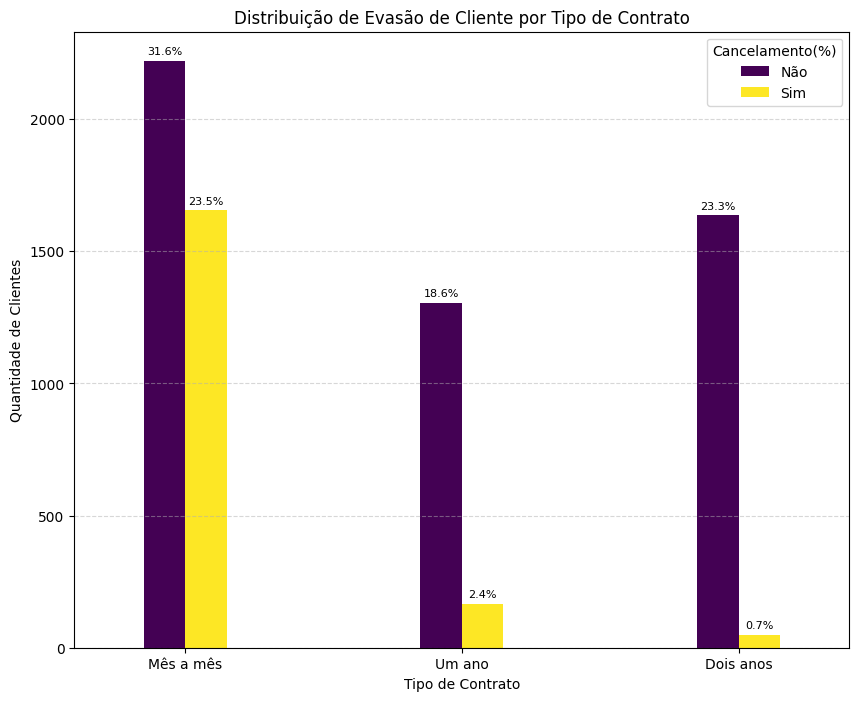

In [154]:
import matplotlib.pyplot as plt
contagem_contrato = df[['Churn', 'tipo_contrato']].value_counts().unstack(fill_value=0)

ordem_contrato = ['Mês a mês', 'Um ano', 'Dois anos']

contagem_contrato_reordenado = contagem_contrato.T.reindex(ordem_contrato)

ax = contagem_contrato_reordenado.plot(kind = 'bar', figsize=(10,8), colormap='viridis', width=0.3, xlabel = 'Tipo de Contrato', ylabel = 'Quantidade de Clientes', title = 'Distribuição de Evasão de Cliente por Tipo de Contrato', rot=(0))
ax.legend(title='Cancelamento(%)', labels = ['Não', 'Sim'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

porcentagem_contrato = (contagem_contrato / len(df)) * 100


ax.bar_label(ax.containers[0], labels=[f'{porcentagem_contrato.loc["Não", ct]:.1f}%' for ct in ordem_contrato], padding=3, fontsize=8)
ax.bar_label(ax.containers[1], labels=[f'{porcentagem_contrato.loc["Sim", ct]:.1f}%' for ct in ordem_contrato], padding=3, fontsize=8)

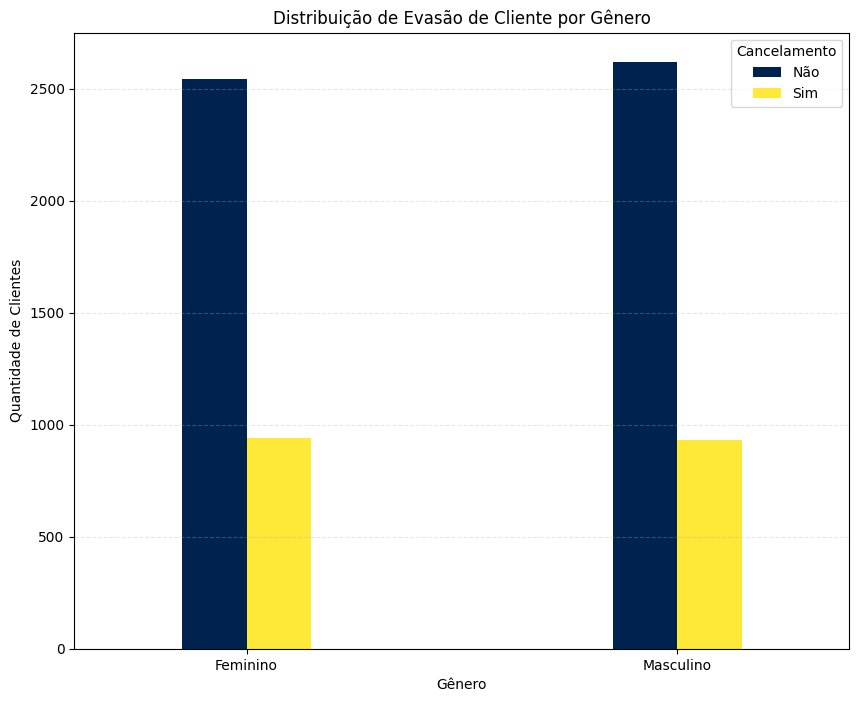

In [116]:
contagem_genero = df[['genero', 'Churn']].value_counts().unstack(fill_value=0)
ax = contagem_genero.plot(kind = 'bar', figsize=(10,8), width=0.3, colormap= 'cividis', xlabel = 'Gênero', ylabel = 'Quantidade de Clientes', title = 'Distribuição de Evasão de Cliente por Gênero', rot=(0))
ax.legend(title='Cancelamento', labels = ['Não', 'Sim'])

porcentagem_genero = (contagem_genero / len(df)) * 100

plt.grid(axis='y', linestyle='--', alpha=0.3)

[Text(0, 3, '6.5%'), Text(0, 3, '18.4%'), Text(0, 3, '1.6%')]

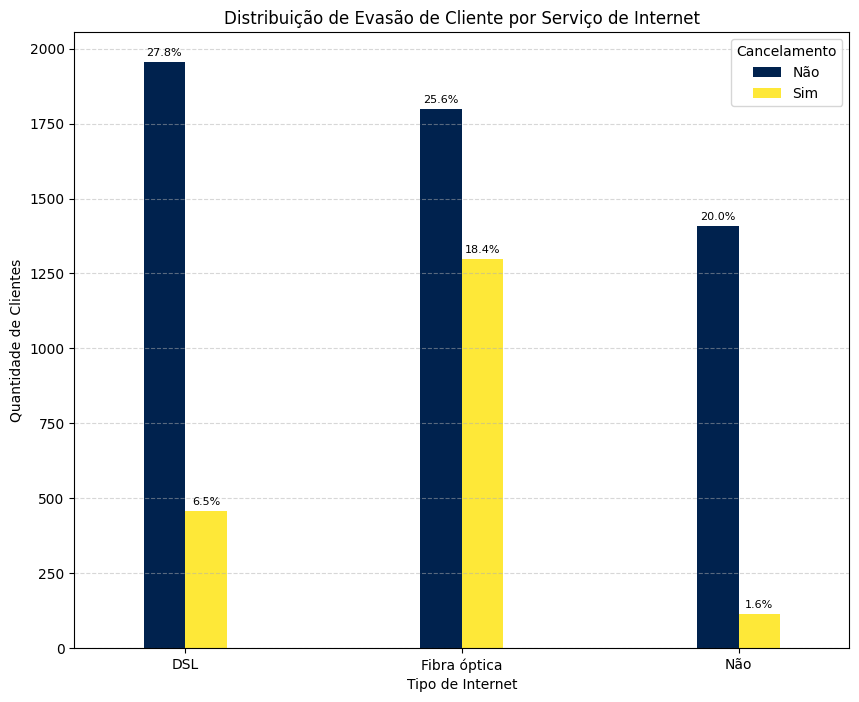

In [181]:
contagem_tipo_internet = df[['Churn', 'tipo_internet']].value_counts().unstack(fill_value=0)

# Transpor o DataFrame para ter 'tipo_internet' no eixo X e 'Churn' como barras agrupadas
ax = contagem_tipo_internet.T.plot(kind = 'bar', figsize=(10,8), colormap='cividis', width=0.3, xlabel = 'Tipo de Internet', ylabel = 'Quantidade de Clientes', title = 'Distribuição de Evasão de Cliente por Serviço de Internet', rot=(0))
ax.legend(title='Cancelamento', labels = ['Não', 'Sim']) # Legenda para 'Não' e 'Sim' Churn
plt.grid(axis='y', linestyle='--', alpha=0.5)

porcentagem_tipo_internet = (contagem_tipo_internet / len(df)) * 100

# Gerar rótulos para as barras 'Não' Churn (primeiro container)
labels_nao = [f'{porcentagem_tipo_internet.loc["Não", ct]:.1f}%' for ct in porcentagem_tipo_internet.columns]
# Gerar rótulos para as barras 'Sim' Churn (segundo container)
labels_sim = [f'{porcentagem_tipo_internet.loc["Sim", ct]:.1f}%' for ct in porcentagem_tipo_internet.columns]

# Aplicar os rótulos às barras dos respectivos containers
ax.bar_label(ax.containers[0], labels=labels_nao, padding=3, fontsize=8)
ax.bar_label(ax.containers[1], labels=labels_sim, padding=3, fontsize=8)

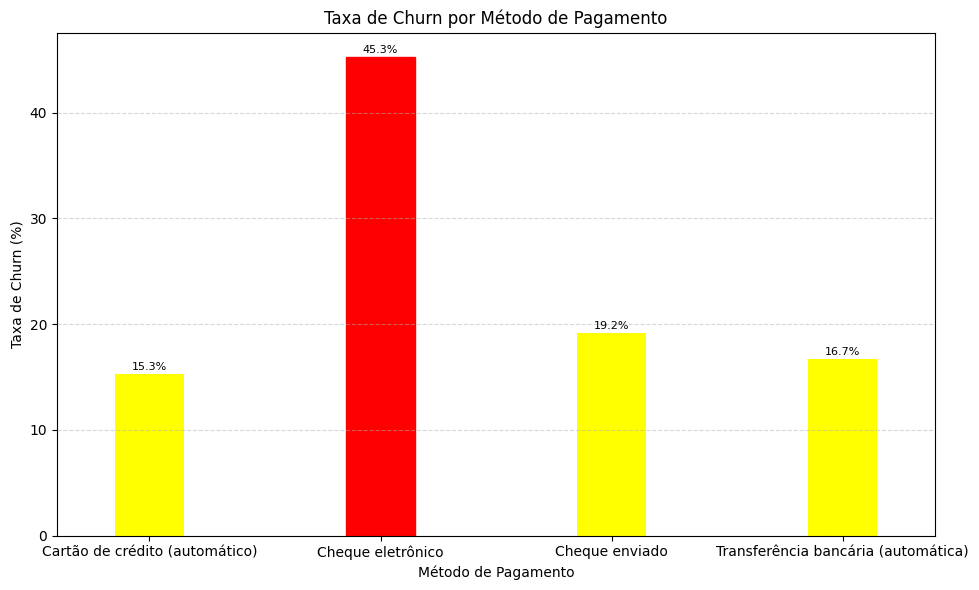

In [178]:
import matplotlib.pyplot as plt

contagem_metodo_pagamento = df.groupby('metodo_pagamento')['Churn'].value_counts().unstack(fill_value=0)

# Calculate percentages of Churn ('Sim') within each payment method
total_clientes_por_metodo = contagem_metodo_pagamento['Sim'] + contagem_metodo_pagamento['Não']
porcentagem_churn_sim_por_metodo = (contagem_metodo_pagamento['Sim'] / total_clientes_por_metodo) * 100

ax = porcentagem_churn_sim_por_metodo.plot(kind='bar', figsize=(10, 6), color='yellow', width=0.3, rot=0,
                                         xlabel='Método de Pagamento',
                                         ylabel='Taxa de Churn (%)',
                                         title='Taxa de Churn por Método de Pagamento')

plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate the bar with the highest churn rate
max_churn_method = porcentagem_churn_sim_por_metodo.idxmax()
max_churn_value = porcentagem_churn_sim_por_metodo.max()

ax.patches[porcentagem_churn_sim_por_metodo.index.get_loc(max_churn_method)].set_color('red') # Highlight the max bar

#ax.text(porcentagem_churn_sim_por_metodo.index.get_loc(max_churn_method), max_churn_value + 1,
 #       f'{max_churn_value:.1f}% (Maior)', ha='center', va='bottom', fontsize=9, color='red', weight='bold')

# Add percentage labels to all bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

In [117]:

churn_tempo_contrato = df.groupby('tempo_contrato')['Churn'].value_counts().unstack(fill_value=0)

# 2. Calcular o total de clientes para cada 'tempo_contrato'
total_clientes_por_tempo = churn_tempo_contrato['Sim'] + churn_tempo_contrato['Não']

# 3. Calcular a porcentagem de churn para cada 'tempo_contrato'
#    Dividimos o número de clientes que cancelaram ('Sim') pelo total de clientes naquele tempo de contrato.
#    Usamos .replace(0, pd.NA) para evitar divisão por zero, e .fillna(0) para tratar casos onde não há clientes.
porcentagem_churn_tempo = (churn_tempo_contrato['Sim'] / total_clientes_por_tempo.replace(0, pd.NA)) * 100
porcentagem_churn_tempo = porcentagem_churn_tempo.fillna(0)

# Exibir a série resultante
display(porcentagem_churn_tempo)

,0
tempo_contrato,
1,61.990212
2,51.680672
3,47.000000
4,47.159091
5,48.120301
...,...
68,9.000000
69,8.421053
70,9.243697


In [118]:
display(porcentagem_churn_tempo)

,0
tempo_contrato,
1,61.990212
2,51.680672
3,47.000000
4,47.159091
5,48.120301
...,...
68,9.000000
69,8.421053
70,9.243697


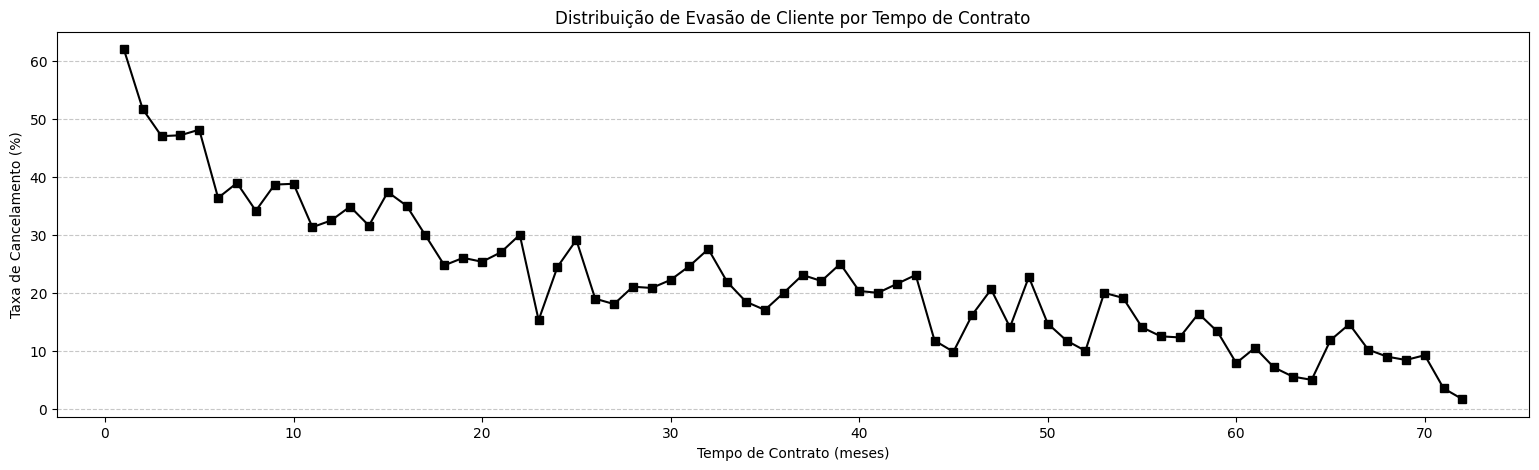

In [119]:
porcentagem_churn_tempo.plot(kind = 'line', figsize=(19,5),
                      marker= 's', mfc='black', mec='black',
                      color='black',
                      xlabel = 'Tempo de Contrato (meses)',
                      ylabel = 'Taxa de Cancelamento (%)',
                      title = 'Distribuição de Evasão de Cliente por Tempo de Contrato')
plt.grid(axis='y', linestyle='--', alpha=0.7)

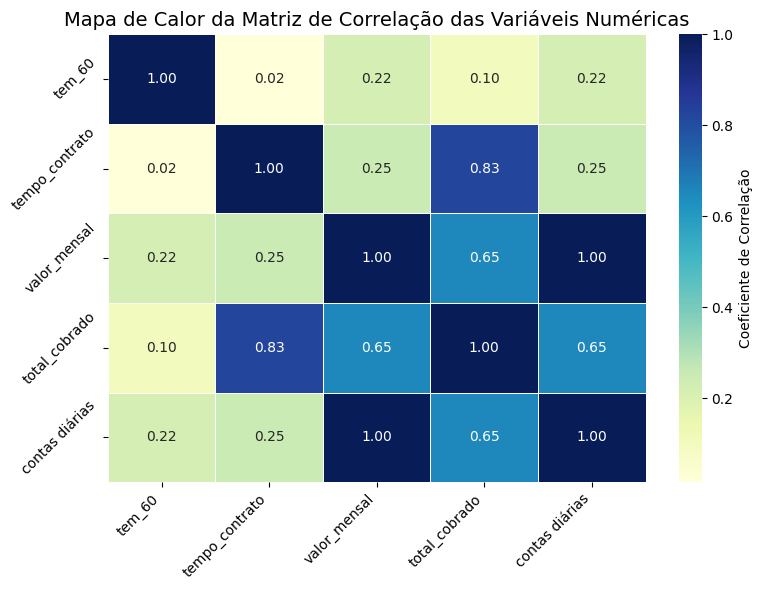

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas as colunas numéricas para o mapa de calor
colunas_numericas = df.select_dtypes(include=['number'])

# Calcular a matriz de correlação
matriz_correlacao = colunas_numericas.corr()

# Criar o mapa de calor com visualizações aprimoradas
plt.figure(figsize=(8, 6)) # Aumentar o tamanho da figura
sns.heatmap(matriz_correlacao,
            annot=True,
            cmap='YlGnBu', # Alterar o mapa de cores para 'viridis'
            fmt=".2f",
            linewidths=.5,
            cbar_kws={'label': 'Coeficiente de Correlação'}, # Adicionar título à barra de cores
            annot_kws={'size': 10}) # Aumentar o tamanho da fonte das anotações

plt.title('Mapa de Calor da Matriz de Correlação das Variáveis Numéricas', fontsize=14)
plt.xticks(rotation=45, ha='right') # Rotacionar rótulos do eixo X
plt.yticks(rotation=45)
plt.tight_layout() # Ajustar o layout para evitar sobreposição
plt.show()

In [121]:
import plotly.express as px
import pandas as pd

# 'matriz_correlacao' is already calculated in the notebook.

# Create the interactive heatmap
fig = px.imshow(matriz_correlacao,
                text_auto='.1f', # Altera para mostrar 1 casa decimal
                aspect="auto",
                color_continuous_scale=px.colors.sequential.YlGnBu,
                title='Mapa de Calor Interativo da Matriz de Correlação das Variáveis Numéricas')

fig.update_layout(
    xaxis_showgrid=False,
    yaxis_showgrid=False,
    xaxis_zeroline=False,
    yaxis_zeroline=False,
    yaxis_autorange='reversed'# To display the heatmap in a more conventional orientation
)

fig.update_xaxes(tickangle=45)

fig.show()

####Relatorio Final

# Challenge-Telecom-X

Análise de Churn TelecomX

Este projeto tem como objetivo principal analisar a evasão de clientes (Churn) na TelecomX, identificando os principais fatores que levam os clientes a cancelar seus serviços. Através de uma abordagem orientada por dados, buscaremos desvendar padrões de Churn para fundamentar a proposição de estratégias eficazes de retenção de clientes.

A compreensão do Churn é de suma importância para qualquer empresa de telecomunicações. A alta taxa de evasão impacta diretamente a receita e lucratividade, pois os custos de aquisição de novos clientes são significativamente mais altos do que os de retenção. Ao mitigar o Churn, a TelecomX pode garantir uma base de clientes mais estável e rentável, otimizando investimentos em marketing e melhorando a percepção de valor dos seus serviços.


### Objetivo
Identificar os principais fatores que levam à evasão de clientes Churn na TelecomX.
Propor estratégias de retenção baseadas em dados para reduzir o Churn e otimizar a lucratividade.

### Preparação de Dados

Extração: Carregamento de dados JSON aninhados do GitHub.
Normalização: Achatamento de colunas aninhadas (cliente, telefone, internet, conta) para um DataFrame plano usando pd.json_normalize.
Limpeza: Remoção de valores vazios em 'Churn' e conversão de para numérico, tratando nulos.
Transformação: Criação de 'contas diárias', renomeação de colunas e tradução de valores categóricos para português.

### Principais Descobertas

Taxa Geral de Churn: 26.58% dos clientes evadem, enquanto 73.4% permaneceram.

Tipo de Contrato:  Clientes com contratos 'Mês a mês' apresentaram uma taxa de Churn alarmante de 23.53%, em contraste com os contratos de 'Um ano' (2.36%) e 'Dois anos' (0.68%). A flexibilidade desses contratos permite que os clientes cancelem facilmente ao menor sinal de insatisfação ou ao encontrar uma oferta mais atraente da concorrência.

Tempo de Contrato: O risco de Churn é exponencialmente maior nos primeiros meses de serviço. O pico de Churn ocorre no primeiro mês (61.99%), seguido de altas taxas nos meses subsequentes (2 meses: 51.68%, 3 meses: 47.00%). Isso indica que a experiência inicial do cliente é um fator crítico para a retenção, e qualquer falha nesse período leva a uma evasão rápida. diminuindo drasticamente com a permanência.

Serviços (Fibra Óptica): Observou-se que 'Fibra óptica' é um tipo de internet de alta demanda. A satisfação e a performance dos serviços de internet são cruciais, e problemas nesse setor podem levar ao Churn, especialmente em contratos de curto prazo.

Pagamento (Cheque Eletrônico): Clientes que utilizam 'Cheque eletrônico' como método de pagamento tendem a ter uma taxa de churn ligeiramente maior (45.31%) em comparação com outros métodos de pagamento. Isso pode indicar uma menor lealdade ou uma facilidade maior para cancelar o serviço.

### Recomendações Estratégicas e Insights

1.  **Incentivar Contratos de Longo Prazo:** Oferecer benefícios exclusivos (descontos, upgrades, meses grátis) para clientes migrarem de contratos Mês a Mês para planos de 1 ou 2 anos.
2.  **Melhorar a Experiência nos Primeiros Meses (Onboarding):** Implementar um programa robusto de 3-5 meses com suporte proativo, verificações de satisfação e comunicação simplificada para resolver problemas rapidamente e fortalecer a lealdade.
3.  **Reavaliar Precificação/Valor Percebido (Contratos Mês a Mês):** Analisar a estrutura de preços e considerar pacotes flexíveis com incentivos de fidelidade ou ajustes de preço para direcionar a escolha do cliente para planos mais estáveis.
4.  **Otimizar Suporte (Internet e Pagamento):** Investigar causas de insatisfação entre usuários de Fibra Óptica e Cheque Eletrônico para aprimorar a qualidade da conexão, tempo de resposta do suporte e facilidade de uso do método de pagamento.

### Conclusão

A TelecomX enfrenta um desafio considerável com sua taxa de Churn. Os esforços de retenção devem ser direcionados primordialmente para a transição de clientes de contratos 'Mês a mês' para opções de longo prazo e para aprimorar drasticamente a experiência do cliente durante os primeiros meses de serviço. Ao implementar essas sugestões, a TelecomX estará em uma posição muito mais forte para estabilizar sua base de clientes e garantir um crescimento sustentável.



